<a href="https://colab.research.google.com/github/Mohamedaminesaadd/desktop/blob/Fetching-before-pull-request-preview/UDOP_DocLayNet_Inference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install -q git+https://github.com/huggingface/transformers.git
!pip install -q datasets sentencepiece bitsandbytes datasets seqeval

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 558.8/558.8 kB 36.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 128.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 96.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 61.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━

In [3]:
! sudo apt install tesseract-ocr
! pip install -q pytesseract

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.


In [6]:
from google.colab import files
from PIL import Image

# Étape 1 : Uploader une image
uploaded = files.upload()

# Étape 2 : Récupérer le nom du fichier uploadé
filename = next(iter(uploaded))




Saving modele-facture-fr-pur-750px.png to modele-facture-fr-pur-750px (2).png


In [5]:
from transformers import UdopForConditionalGeneration
import torch
from datasets import load_dataset
from datasets.features import ClassLabel
from PIL import ImageDraw, ImageFont, Image
import pytesseract
import random
from huggingface_hub import notebook_login

In [9]:
# Étape 3 : Ouvrir et convertir l'image
image = Image.open(filename)
image = image.convert("RGB")

# Étape 4 (optionnel) : Afficher l’image
image.show()

In [10]:
ocr_df = pytesseract.image_to_data(image, output_type='data.frame')
ocr_df = ocr_df.dropna().reset_index(drop=True)

In [11]:
# https://huggingface.co/datasets/nielsr/funsd-layoutlmv3/blob/main/funsd-layoutlmv3.py
def get_line_bbox( bboxs):
        x = [bboxs[i][j] for i in range(len(bboxs)) for j in range(0, len(bboxs[i]), 2)]
        y = [bboxs[i][j] for i in range(len(bboxs)) for j in range(1, len(bboxs[i]), 2)]

        x0, y0, x1, y1 = min(x), min(y), max(x), max(y)

        assert x1 >= x0 and y1 >= y0
        bbox = [x0, y0, x1, y1]
        return bbox

In [12]:
texts_list = []
bboxs_list =[]

for i, j in ocr_df.groupby('block_num'):
  text = ' '.join(j['text'])
  if text != ' ' and text.strip()!='':
    texts_list.append(text)
    box = []
    for left, top, width, height in zip(j['left'].tolist(), j['top'].tolist(), j['width'].tolist(), j['height'].tolist()):
      box.append([left, top, left+width, top+height])

    bboxs_list.append(get_line_bbox(box))

In [13]:
image_path = "test.png"

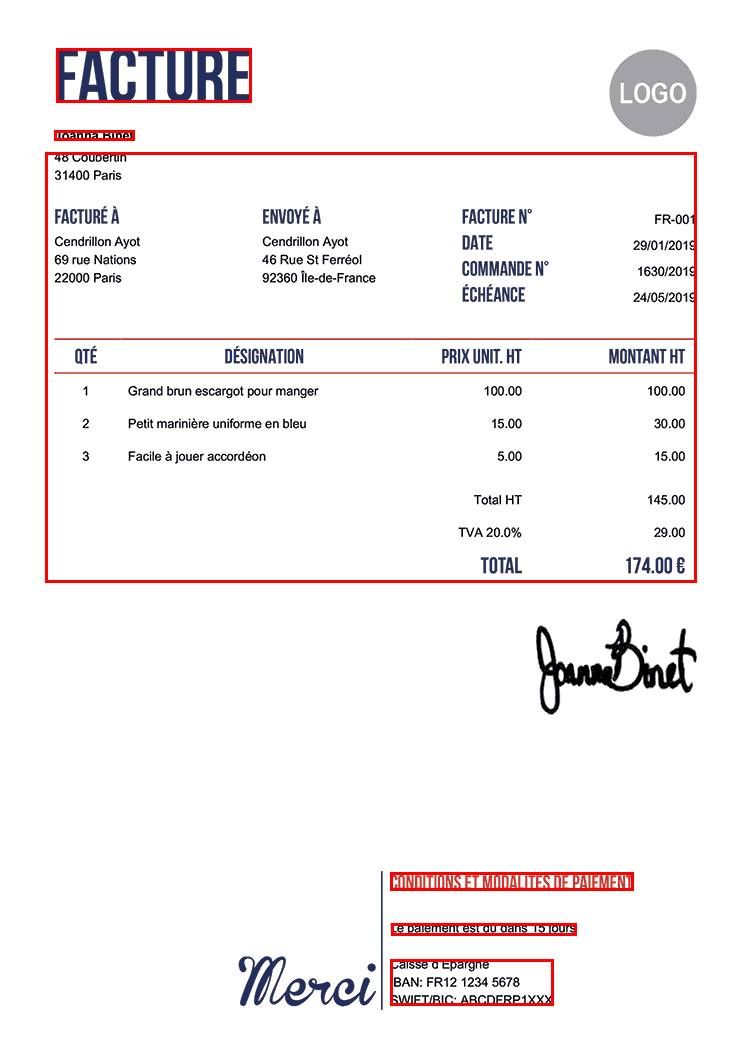

In [16]:
# Load the image
# image screenshot https://www.researchgate.net/publication/354983472_BERT_got_a_Date_Introducing_Transformers_to_Temporal_Tagging
image = Image.open(filename)
draw = ImageDraw.Draw(image)
# Define the bounding box
for bounding_box in bboxs_list:
    draw.rectangle(bounding_box, outline="red", width=3)
image

In [17]:
# Normalize box diamentions to range 0 to 1000
def normalized_box(box, image_width=1025, image_height=1025):
    return [
        int(1000 * (box[0] / image_width)),
        int(1000 * (box[1] / image_height)),
        int(1000 * (box[2] / image_width)),
        int(1000 * (box[3] / image_height)),
    ]
def convert_box(bbox):
    x, y, w, h = tuple(bbox) # Box coordinates are in (left, top, width, height) format
    return [x, y, x+w, y+h] # we need to convert it into (x1, y1, x2, y2) which is (left, top, left+widght, top+height)

In [18]:
from transformers import UdopForConditionalGeneration, AutoProcessor, AutoModelForTokenClassification

model_name = 'Mit1208/UDOP-finetuned-DocLayNet-1'
processor = AutoProcessor.from_pretrained(model_name)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/760 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

In [20]:
from transformers import UdopEncoderModel, UdopPreTrainedModel, UdopConfig
from transformers.modeling_outputs import TokenClassifierOutput
from torch import nn

class UdopForTokenClassification(UdopPreTrainedModel):
  def __init__(self, config):
    super().__init__(config)

    self.udop = UdopEncoderModel.from_pretrained(model_name)
    self.num_labels = config.num_labels

    self.dropout = nn.Dropout(0.5)
    self.classifier = nn.Linear(config.hidden_size, config.num_labels)

  def forward(self, input_ids, bbox, attention_mask, pixel_values, labels=None):
    outputs = self.udop(input_ids=input_ids, bbox=bbox, attention_mask=attention_mask, pixel_values=pixel_values)
    sequence_output = outputs[0]

    seq_length = input_ids.shape[1]
    # only take the text part of the output representations
    sequence_output = outputs[0][:, :seq_length]
    sequence_output = self.dropout(sequence_output)

    logits = self.classifier(sequence_output)

    loss = None
    if labels is not None:
        loss_fct = nn.CrossEntropyLoss()
        loss = loss_fct(logits.view(-1, self.num_labels), labels.view(-1))

    return TokenClassifierOutput(
        loss=loss,
        logits=logits,
        hidden_states=outputs.hidden_states,
        attentions=outputs.attentions,
    )

In [21]:
model = UdopForTokenClassification.from_pretrained("Mit1208/UDOP-finetuned-DocLayNet-1")

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.36G [00:00<?, ?B/s]

Some weights of UdopEncoderModel were not initialized from the model checkpoint at Mit1208/UDOP-finetuned-DocLayNet-1 and are newly initialized: ['encoder.block.0.layer.0.SelfAttention.k.weight', 'encoder.block.0.layer.0.SelfAttention.o.weight', 'encoder.block.0.layer.0.SelfAttention.q.weight', 'encoder.block.0.layer.0.SelfAttention.relative_attention_bias.weight', 'encoder.block.0.layer.0.SelfAttention.v.weight', 'encoder.block.0.layer.0.layer_norm.weight', 'encoder.block.0.layer.1.DenseReluDense.wi.weight', 'encoder.block.0.layer.1.DenseReluDense.wo.weight', 'encoder.block.0.layer.1.layer_norm.weight', 'encoder.block.1.layer.0.SelfAttention.k.weight', 'encoder.block.1.layer.0.SelfAttention.o.weight', 'encoder.block.1.layer.0.SelfAttention.q.weight', 'encoder.block.1.layer.0.SelfAttention.v.weight', 'encoder.block.1.layer.0.layer_norm.weight', 'encoder.block.1.layer.1.DenseReluDense.wi.weight', 'encoder.block.1.layer.1.DenseReluDense.wo.weight', 'encoder.block.1.layer.1.layer_norm.wei

In [35]:
from google.colab import files
uploaded = files.upload()
image_path = next(iter(uploaded))
img = Image.open(image_path).convert("RGB").resize((1000, 1000))


Saving Capture d_écran 2025-07-07 102731.png to Capture d_écran 2025-07-07 102731.png


In [36]:
img = Image.open(image_path).convert('RGB').resize((1000, 1000))
image_width, image_height = img.size
normalized_bboxes_list = [normalized_box((bboxs), image_width, image_height) for bboxs in bboxs_list]

In [37]:
encoding = processor(img, texts_list, boxes=normalized_bboxes_list, truncation=True, padding="max_length", max_length=512, return_tensors="pt")
outputs = model(**encoding)

In [38]:
label_list = list(model.config.label2id.keys())
get_colors = lambda n: list(map(lambda i: "#" + "%06x" % random.randint(0, 0xFFFFFF),range(n)))
colors = get_colors(len(label_list))
font = ImageFont.load_default()
label2color = {label: colors[idx] for idx, label in enumerate(label_list)}

In [39]:
logits = outputs.logits
predictions = logits.argmax(-1).squeeze().tolist()
token_boxes = encoding.bbox.squeeze().tolist()

In [40]:
# Initialize variables to store the filtered lists and the previous bounding box
filtered_predictions = []
filtered_token_boxes = []
previous_box = None

# Iterate through predictions and token_boxes simultaneously
for prediction, token_box in zip(predictions, token_boxes):
    # If the current bounding box is different from the previous one,
    # add the corresponding prediction to the filtered list
    if token_box != previous_box:
        filtered_predictions.append(prediction)
        filtered_token_boxes.append(token_box)
        previous_box = token_box  # Update previous_box to the current bounding box

# Print the filtered lists
print(filtered_predictions)
print(filtered_token_boxes)


[5, 7, 8, 7, 9, 9, 3, 4]
[[56, 48, 251, 102], [54, 130, 134, 140], [45, 152, 696, 582], [390, 872, 633, 890], [391, 923, 576, 935], [390, 959, 553, 1004], [1000, 1000, 1000, 1000], [0, 0, 0, 0]]


In [41]:
def unnormalize_box(bbox, width, height):
    # print(bbox)
    return [
         width * (bbox[0] / 1000),
         height * (bbox[1] / 1000),
         width * (bbox[2] / 1000),
         height * (bbox[3] / 1000),
     ]


width, height = img.size
print(width, height)


1000 1000


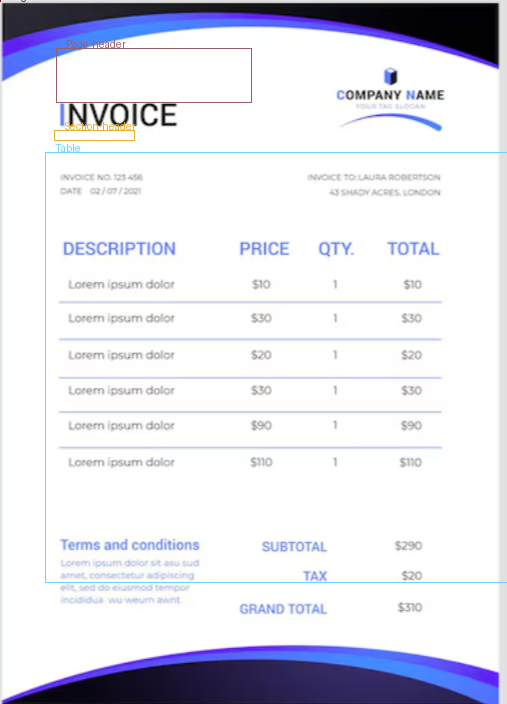

In [42]:
from PIL import ImageDraw, ImageFont

test_image = Image.open(image_path)
test_draw = ImageDraw.Draw(test_image)
font = ImageFont.load_default()

def iob_to_label(label):
    # label = label[2:]
    if not label:
      return 'other'
    return label


for predicted_label, box in zip(filtered_predictions, filtered_token_boxes):
    predicted_label = model.config.id2label[predicted_label]
    test_draw.rectangle(box, outline=label2color[predicted_label])
    test_draw.text((box[0] + 10, box[1] - 10), text=predicted_label, fill=label2color[predicted_label], font=font)

test_image

## Reference
1. https://github.com/NielsRogge/Transformers-Tutorials/blob/master/UDOP/Fine_tune_UDOPEncoderModel_on_FUNSD_(HuggingFace_Trainer).ipynb
2. https://github.com/mit1280/Document-AI/blob/main/LayoutLMv3_Inference.ipynb